In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import torch
from torch import nn
from sklearn.metrics import r2_score

# Set plotting style
sns.set(style="whitegrid")

# Load the dataset
file_path = '/content/124ddc35-e067-4af0-95ff-c5f6095529ee_Data.csv'
df_raw = pd.read_csv(file_path)
print(f"Raw data shape: {df_raw.shape}")
# Preview the first few rows
display(df_raw.head())

Raw data shape: (65, 50)


,Country Name,Country Code,Series Name,Series Code,1980 [YR1980],1981 [YR1981],1982 [YR1982],1983 [YR1983],1984 [YR1984],1985 [YR1985],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,France,FRA,Electric power consumption (kWh per capita),EG.USE.ELEC.KH.PC,..,..,..,..,..,..,...,7.276876e+03,7.229039e+03,7.156817e+03,7.059075e+03,6.685615e+03,6.950700e+03,6649.38931756837,6415.02611160317,6447.21141881145,..
1,France,FRA,Energy use (kg of oil equivalent per capita),EG.USE.PCAP.KG.OE,..,..,..,..,..,..,...,3.718171e+03,3.705411e+03,3.669371e+03,3.605532e+03,3.228489e+03,3.469834e+03,3100.1897815932,3136.12237461475,3184.7895085475,..
2,France,FRA,GDP (current US$),NY.GDP.MKTP.CD,694529183483.39,609184791792.396,578152310609.841,553356312935.709,525033325827.516,547220981165.134,...,2.470408e+12,2.588868e+12,2.781576e+12,2.722794e+12,2.647926e+12,2.966434e+12,2794788137066.94,3056250648138.29,3160442622465.08,..
3,France,FRA,"Population, total",SP.POP.TOTL,55274184,55603353,55806789,56108330,56383085,56665619,...,6.672410e+07,6.691802e+07,6.715835e+07,6.738206e+07,6.760111e+07,6.784281e+07,68184457,68372286,68551653,..
4,France,FRA,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,..,..,..,..,..,..,...,1.420000e+01,1.410000e+01,1.520000e+01,1.550000e+01,1.680000e+01,1.620000e+01,..,..,..,..


In [ ]:
df = df_raw.copy()

# Drop rows where 'Country Name' is missing or irrelevant metadata
irrelevant = ['Data from database: World Development Indicators', 'Last Updated: 04/08/2026']
df = df[~df['Country Name'].isin(irrelevant)]

year_cols = [col for col in df.columns if 'YR' in col]

# Replace placeholders for missing values with NaN
for col in year_cols:
    df[col] = df[col].replace(['..', '...', '.', ' ..', '  ..', ''], np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['Series Name'])

# Melt the DataFrame to the long format
long_df = df.melt(id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
                  value_vars=year_cols,
                  var_name='Year', value_name='Value')

long_df['Year'] = long_df['Year'].str.extract('(\d{4})').astype(int)

pivot_df = long_df.pivot_table(index=['Country Name', 'Year'],
                               columns='Series Name', values='Value')

pivot_df = pivot_df.sort_index(level=['Country Name', 'Year'])

display(pivot_df.head(10))

<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1568/45359887.py:28: SyntaxWarning: invalid escape sequence '\d'
  long_df['Year'] = long_df['Year'].str.extract('(\d{4})').astype(int)
/tmp/ipykernel_1568/45359887.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(['..', '...', '.', ' ..', '  ..', ''], np.nan)


Series Name        Electric power consumption (kWh per capita)  \
Country Name Year                                                
China        1980                                          NaN   
             1981                                          NaN   
             1982                                          NaN   
             1983                                          NaN   
             1984                                          NaN   
             1985                                          NaN   
             1986                                          NaN   
             1987                                          NaN   
             1988                                          NaN   
             1989                                          NaN   

Series Name        Energy use (kg of oil equivalent per capita)  \
Country Name Year                                                 
China        1980                                           NaN   
             1981                                           NaN   
             1982                                           NaN   
             1983                                           NaN   
             1984                                           NaN   
             1985                                           NaN   
             1986                                           NaN   
             1987                                           NaN   
             1988                                           NaN   
             1989                                           NaN   

Series Name        Fossil fuel energy consumption (% of total)  \
Country Name Year                                                
China        1980                                          NaN   
             1981                                          NaN   
             1982                                          NaN   
             1983                                          NaN   
             1984                                          NaN   
             1985                                          NaN   
             1986                                          NaN   
             1987                                          NaN   
             1988                                          NaN   
             1989                                          NaN   

Series Name        GDP (current US$)  Population, total  \
Country Name Year                                         
China        1980       1.914875e+11       9.812350e+08   
             1981       1.962183e+11       9.938850e+08   
             1982       2.054809e+11       1.008630e+09   
             1983       2.311303e+11       1.023310e+09   
             1984       2.604429e+11       1.036825e+09   
             1985       3.100646e+11       1.051040e+09   
             1986       3.013101e+11       1.066790e+09   
             1987       2.734552e+11       1.084035e+09   
             1988       3.128889e+11       1.101630e+09   
             1989       3.483806e+11       1.118650e+09   

Series Name        Renewable energy consumption (% of total final energy consumption)  
Country Name Year                                                                      
China        1980                                                NaN                   
             1981                                                NaN                   
             1982                                                NaN                   
             1983                                                NaN                   
             1984                                                NaN                   
             1985                                                NaN                   
             1986                                                NaN                   
             1987                                                NaN                   
             1988   

In [ ]:
# Interpolate missing values
pivot_interpolated = pivot_df.groupby(level=0, group_keys=False).apply(lambda group: group.interpolate(method='linear'))

# Fill any remaining missing values at the start or end with forward/backward fill
pivot_interpolated = pivot_interpolated.groupby(level=0, group_keys=False).apply(lambda group: group.bfill().ffill())

pivot_interpolated = pivot_interpolated.reset_index()

print("Data after interpolation (first few rows):")
display(pivot_interpolated.head(10))

Data after interpolation (first few rows):


Series Name,Country Name,Year,Electric power consumption (kWh per capita),Energy use (kg of oil equivalent per capita),Fossil fuel energy consumption (% of total),GDP (current US$),"Population, total",Renewable energy consumption (% of total final energy consumption)
0,China,1980,510.619855,773.250117,75.096752,1.914875e+11,9.812350e+08,33.9
1,China,1981,510.619855,773.250117,75.096752,1.962183e+11,9.938850e+08,33.9
2,China,1982,510.619855,773.250117,75.096752,2.054809e+11,1.008630e+09,33.9
3,China,1983,510.619855,773.250117,75.096752,2.311303e+11,1.023310e+09,33.9
4,China,1984,510.619855,773.250117,75.096752,2.604429e+11,1.036825e+09,33.9
5,China,1985,510.619855,773.250117,75.096752,3.100646e+11,1.051040e+09,33.9
6,China,1986,510.619855,773.250117,75.096752,3.013101e+11,1.066790e+09,33.9
7,China,1987,510.619855,773.250117,75.096752,2.734552e+11,1.084035e+09,33.9
8,China,1988,510.619855,773.250117,75.096752,3.128889e+11,1.101630e+09,33.9
9,China,1989,510.619855,773.250117,75.096752,3.483806e+11,1.118650e+09,33.9


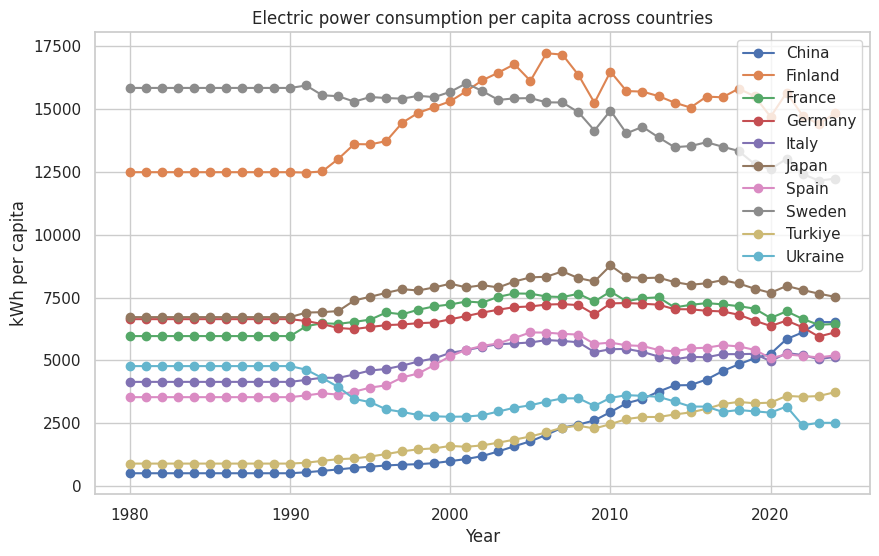

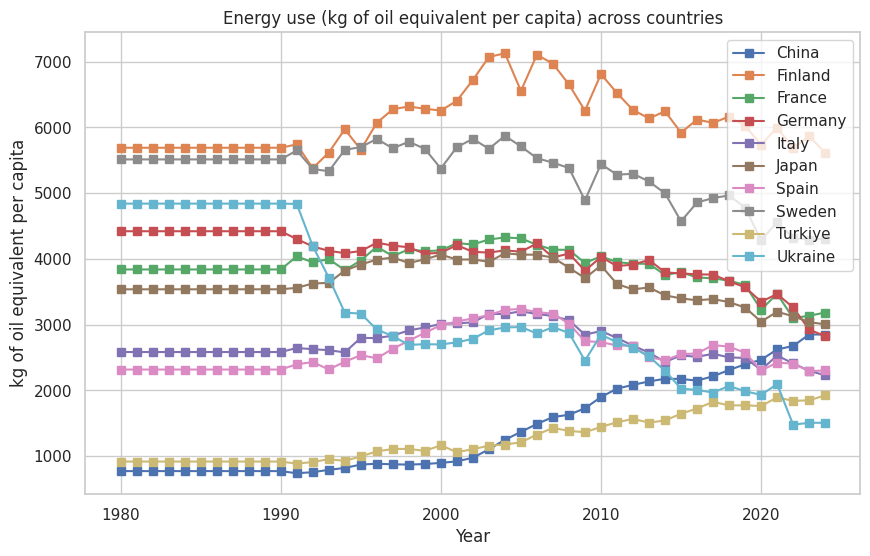

In [ ]:
# Plot electric power consumption per capita across all countries
plt.figure(figsize=(10,6))
for country_name, group in pivot_interpolated.groupby('Country Name'):
    plt.plot(group['Year'], group['Electric power consumption (kWh per capita)'], marker='o', label=country_name)
plt.title('Electric power consumption per capita across countries')
plt.xlabel('Year')
plt.ylabel('kWh per capita')
plt.legend()
plt.grid(True)
plt.show()

# Plot energy use per capita across all countries
plt.figure(figsize=(10,6))
for country_name, group in pivot_interpolated.groupby('Country Name'):
    plt.plot(group['Year'], group['Energy use (kg of oil equivalent per capita)'], marker='s', label=country_name)
plt.title('Energy use (kg of oil equivalent per capita) across countries')
plt.xlabel('Year')
plt.ylabel('kg of oil equivalent per capita')
plt.legend()
plt.grid(True)
plt.show()


--- China ---
RMSE: 195.72 | MAE: 157.45
LSTMRegressor(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Predicted electric power consumption per capita in 2025 for China: 6152.66 kWh
[np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034)]
[np.float32(6152.6646), np.float32(6192.138), np.float32(6181.7886), np.float32(6160.169), np.float32(6161.231), np.float32(6159.4263), np.float32(6158.0386), np.float32(6157.9497), np.float32(6157.7544), np.float32(6157.6533)]
Mape: 13.26089587544151
R2: 0.9898719495315732
____Future Predictions____


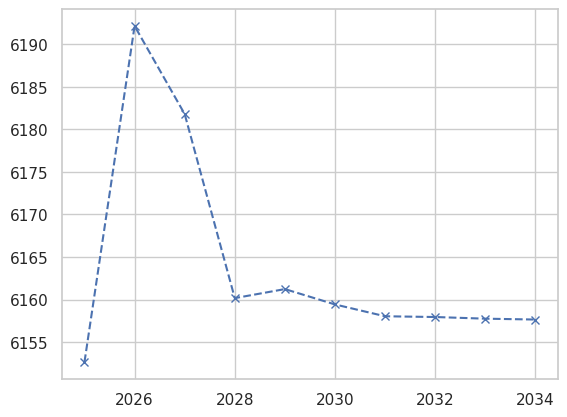

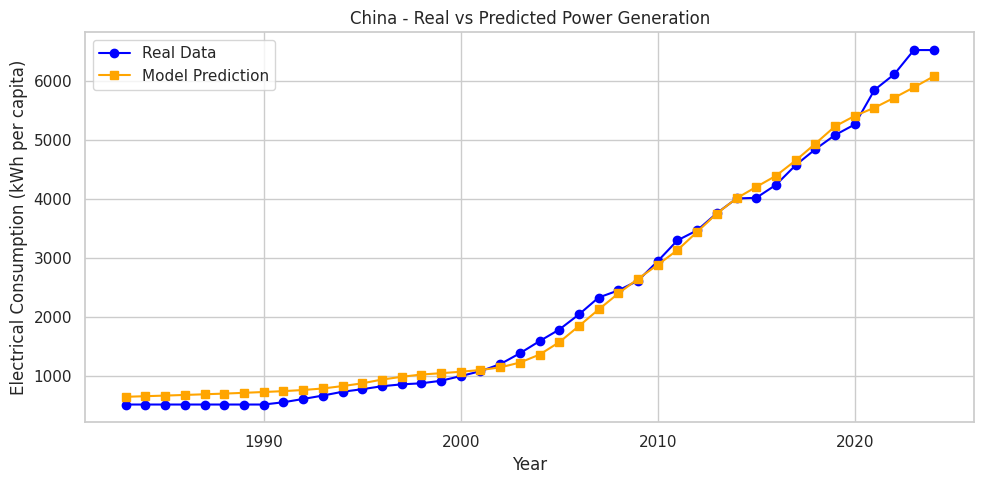


--- Finland ---
RMSE: 421.40 | MAE: 340.66
LSTMRegressor(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Predicted electric power consumption per capita in 2025 for Finland: 14432.07 kWh
[np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034)]
[np.float32(14432.068), np.float32(14389.613), np.float32(14319.751), np.float32(14253.476), np.float32(14230.98), np.float32(14209.943), np.float32(14195.375), np.float32(14187.794), np.float32(14182.057), np.float32(14178.363)]
Mape: 2.294718841624322
R2: 0.9206452850675715
____Future Predictions____


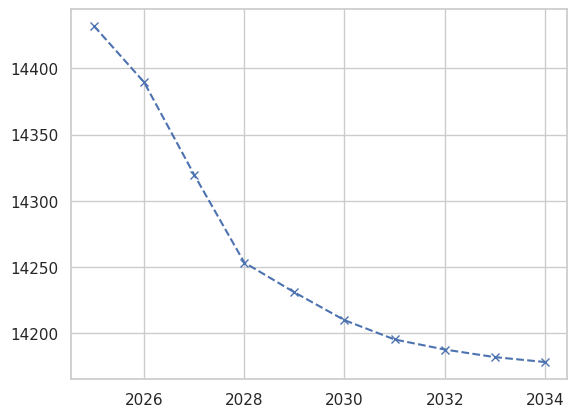

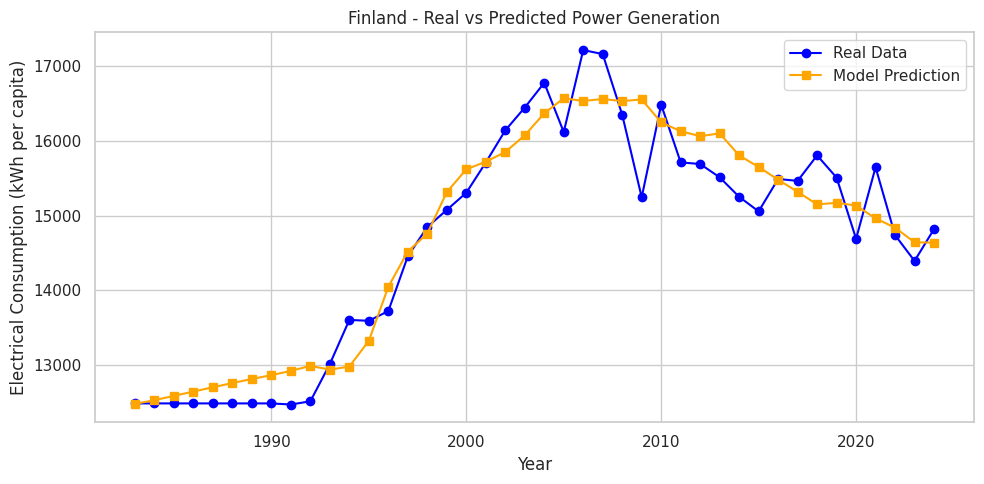


--- France ---
RMSE: 132.17 | MAE: 101.55
LSTMRegressor(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Predicted electric power consumption per capita in 2025 for France: 6326.64 kWh
[np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034)]
[np.float32(6326.6445), np.float32(6305.0903), np.float32(6302.9927), np.float32(6274.152), np.float32(6266.3027), np.float32(6260.1226), np.float32(6252.289), np.float32(6248.831), np.float32(6245.8975), np.float32(6243.4287)]
Mape: 1.4748295115125412
R2: 0.9479830076670533
____Future Predictions____


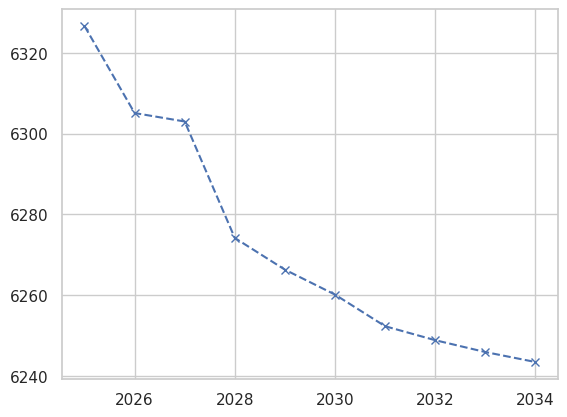

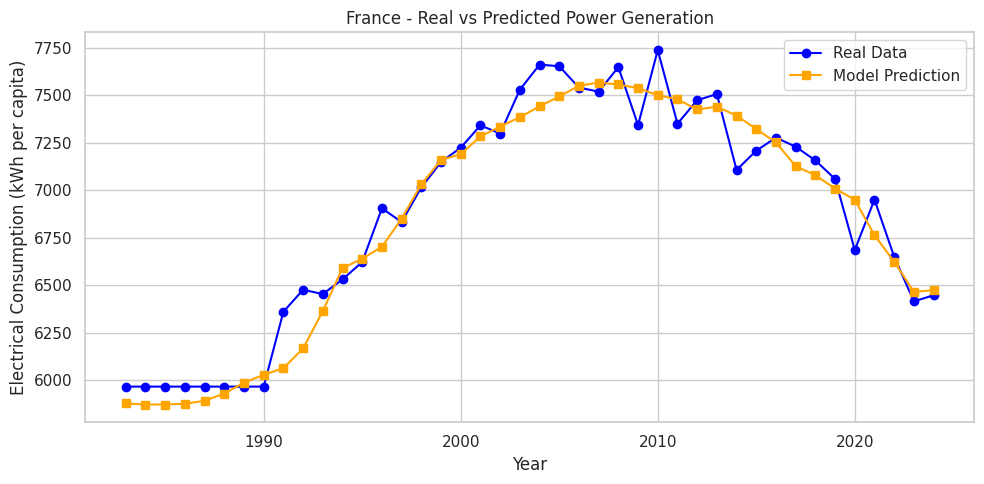


--- Germany ---
RMSE: 147.34 | MAE: 115.53
LSTMRegressor(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Predicted electric power consumption per capita in 2025 for Germany: 6151.45 kWh
[np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034)]
[np.float32(6151.4517), np.float32(6133.3765), np.float32(6151.236), np.float32(6154.8594), np.float32(6154.7197), np.float32(6156.851), np.float32(6157.3237), np.float32(6157.5186), np.float32(6157.791), np.float32(6157.871)]
Mape: 1.737667081732694
R2: 0.8172677187851319
____Future Predictions____


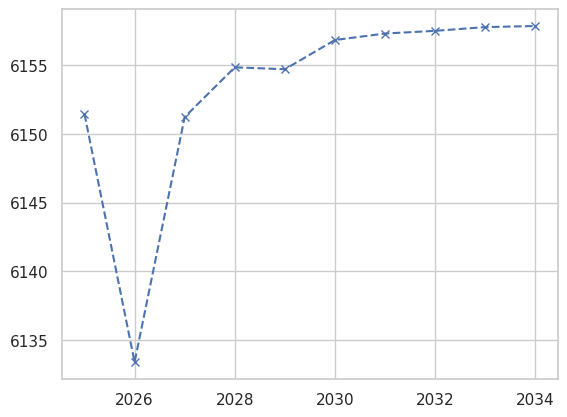

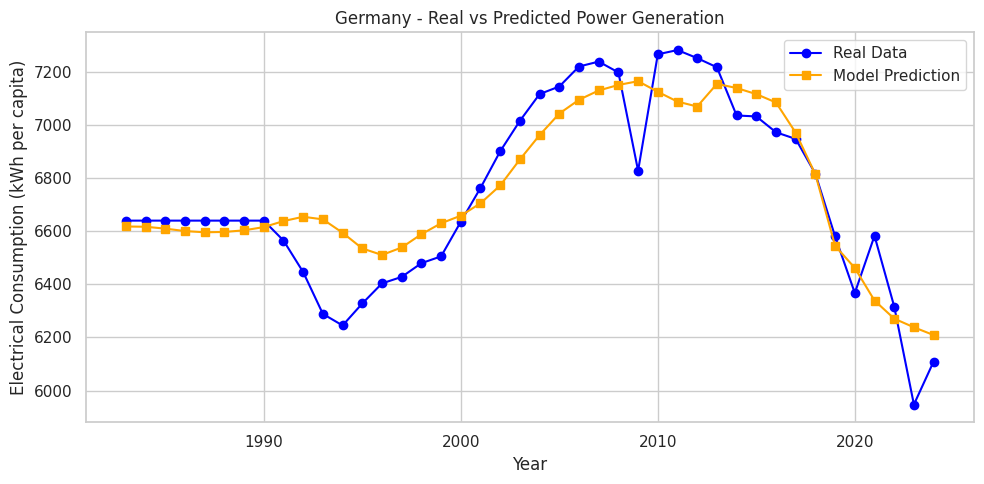


--- Italy ---
RMSE: 131.77 | MAE: 104.88
LSTMRegressor(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Predicted electric power consumption per capita in 2025 for Italy: 4966.92 kWh
[np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034)]
[np.float32(4966.9224), np.float32(4909.4263), np.float32(4881.429), np.float32(4833.981), np.float32(4811.396), np.float32(4794.3047), np.float32(4778.189), np.float32(4768.3145), np.float32(4760.53), np.float32(4754.3364)]
Mape: 2.045671107133837
R2: 0.9426720614401313
____Future Predictions____


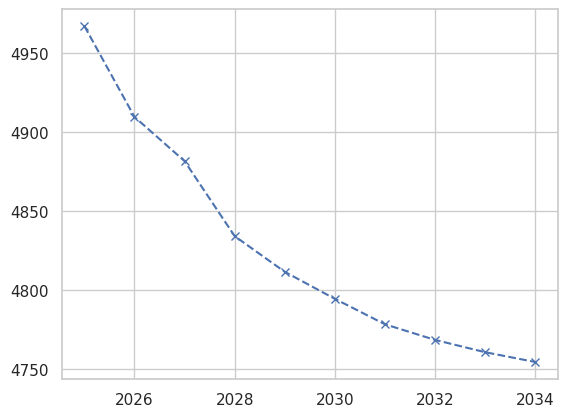

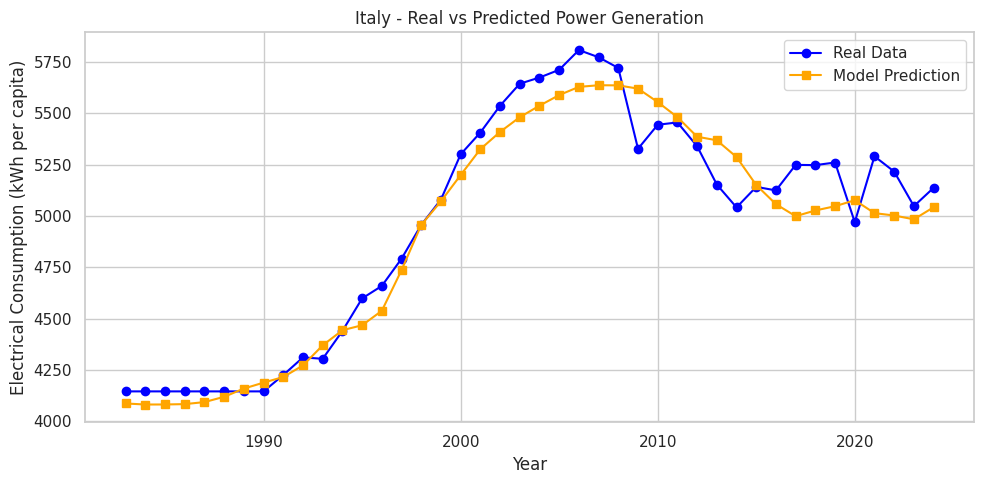


--- Japan ---
RMSE: 153.13 | MAE: 123.33
LSTMRegressor(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Predicted electric power consumption per capita in 2025 for Japan: 7442.91 kWh
[np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034)]
[np.float32(7442.91), np.float32(7332.88), np.float32(7257.8843), np.float32(7215.26), np.float32(7178.4585), np.float32(7154.4307), np.float32(7138.6943), np.float32(7126.948), np.float32(7119.1846), np.float32(7113.901)]
Mape: 1.5788298487854495
R2: 0.9352861541991396
____Future Predictions____


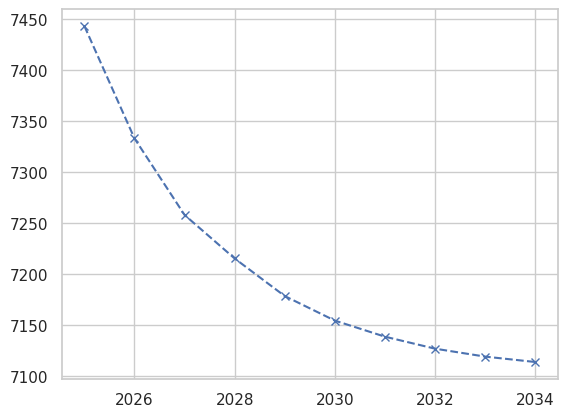

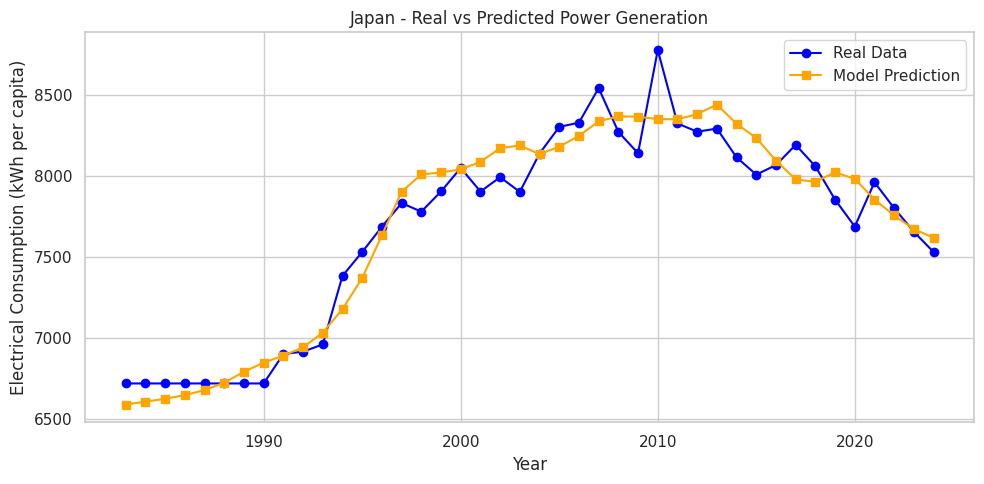


--- Spain ---
RMSE: 131.71 | MAE: 101.83
LSTMRegressor(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Predicted electric power consumption per capita in 2025 for Spain: 5076.00 kWh
[np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034)]
[np.float32(5076.001), np.float32(5053.9985), np.float32(5063.538), np.float32(5049.0137), np.float32(5046.3857), np.float32(5045.712), np.float32(5043.7905), np.float32(5043.2725), np.float32(5042.956), np.float32(5042.665)]
Mape: 2.095184016698152
R2: 0.9796562380051417
____Future Predictions____


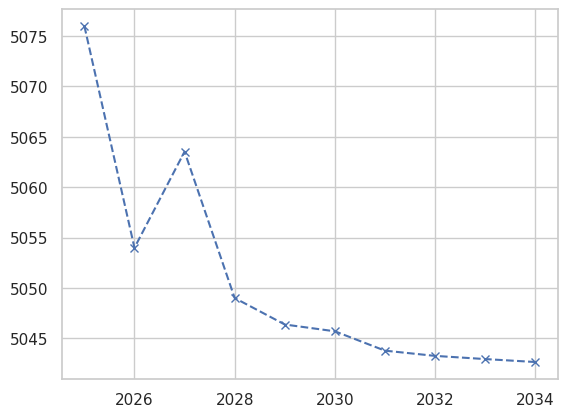

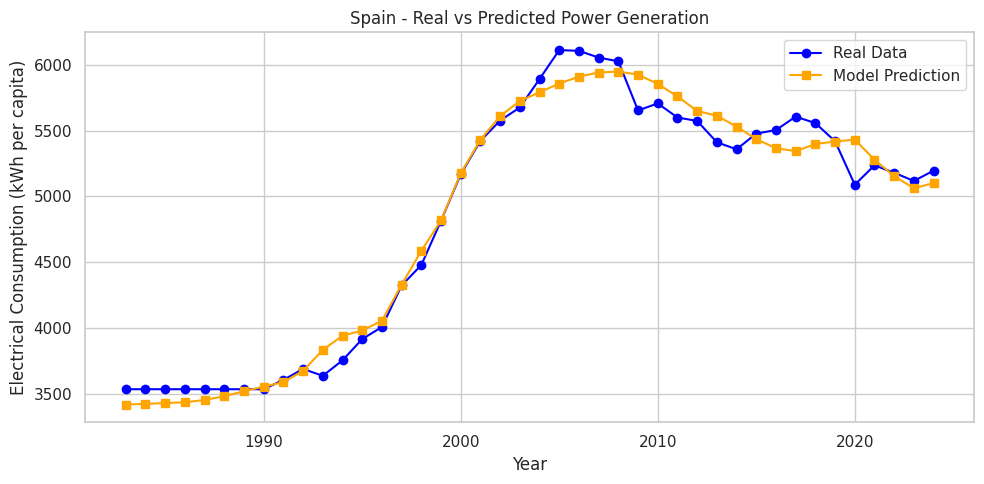


--- Sweden ---
RMSE: 254.03 | MAE: 195.41
LSTMRegressor(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Predicted electric power consumption per capita in 2025 for Sweden: 12460.11 kWh
[np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034)]
[np.float32(12460.106), np.float32(12454.12), np.float32(12456.0205), np.float32(12460.376), np.float32(12460.352), np.float32(12460.464), np.float32(12460.549), np.float32(12460.551), np.float32(12460.555), np.float32(12460.557)]
Mape: 1.3489184326406718
R2: 0.9546565451178415
____Future Predictions____


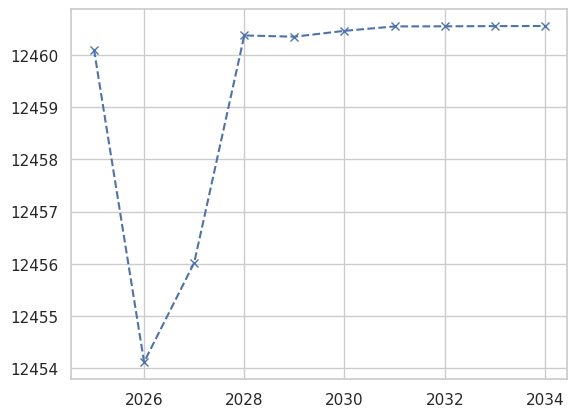

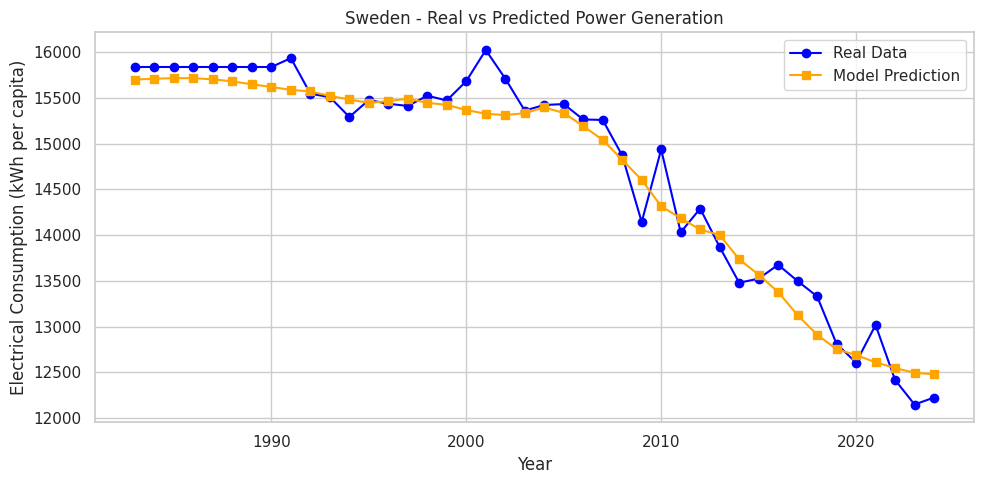


--- Turkiye ---
RMSE: 113.45 | MAE: 92.16
LSTMRegressor(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Predicted electric power consumption per capita in 2025 for Turkiye: 3513.32 kWh
[np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034)]
[np.float32(3513.323), np.float32(3548.8752), np.float32(3569.9465), np.float32(3562.1067), np.float32(3564.3096), np.float32(3565.026), np.float32(3564.7751), np.float32(3564.895), np.float32(3564.9211), np.float32(3564.915)]
Mape: 4.717126209381112
R2: 0.9859373332778258
____Future Predictions____


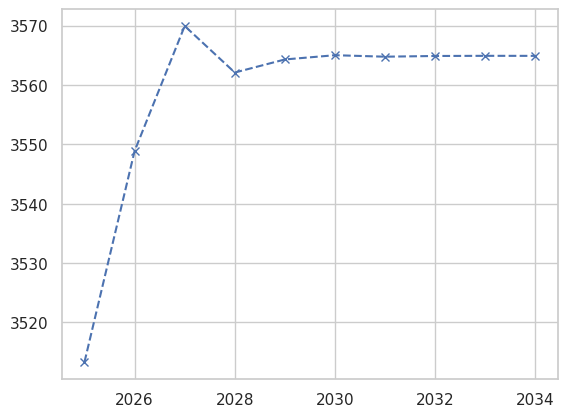

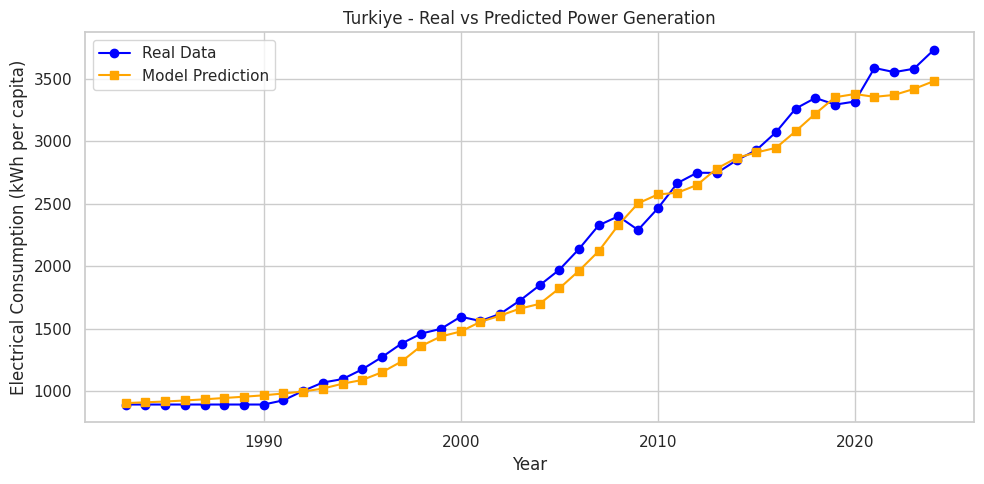


--- Ukraine ---
RMSE: 239.07 | MAE: 197.88
LSTMRegressor(
  (lstm): LSTM(6, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Predicted electric power consumption per capita in 2025 for Ukraine: 2803.73 kWh
[np.int64(2025), np.int64(2026), np.int64(2027), np.int64(2028), np.int64(2029), np.int64(2030), np.int64(2031), np.int64(2032), np.int64(2033), np.int64(2034)]
[np.float32(2803.732), np.float32(2846.2712), np.float32(2873.4526), np.float32(2894.877), np.float32(2901.172), np.float32(2904.9631), np.float32(2907.0237), np.float32(2907.8625), np.float32(2908.3184), np.float32(2908.5437)]
Mape: 5.91374203114049
R2: 0.8973419368823946
____Future Predictions____


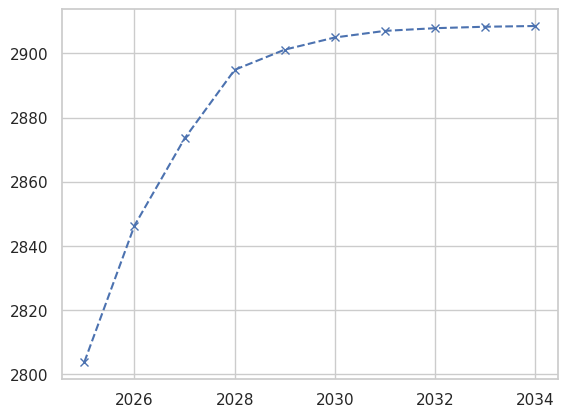

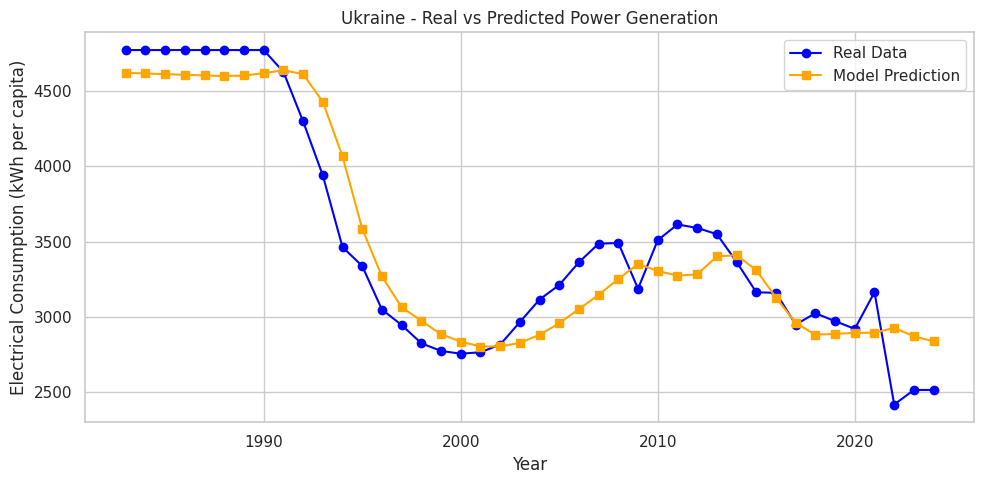

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        output = self.fc(last_hidden)
        return output

countries = pivot_interpolated['Country Name'].unique()

features = ['Electric power consumption (kWh per capita)',
            'Energy use (kg of oil equivalent per capita)', 'GDP (current US$)',
            'Population, total', 'Renewable energy consumption (% of total final energy consumption)',
            'Fossil fuel energy consumption (% of total)']
target = 'Electric power consumption (kWh per capita)'
sequence_length = 3

for country in countries:
    df_c = pivot_interpolated[pivot_interpolated['Country Name'] == country].copy()

    if len(df_c) <= sequence_length:
        continue

    X = df_c[features].values
    y = df_c[target].values.reshape(-1, 1)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y)

    X_seq, y_seq = [], []
    for i in range(len(X_scaled) - sequence_length):
        X_seq.append(X_scaled[i:i+sequence_length])
        y_seq.append(y_scaled[i+sequence_length])

    if not X_seq:
        continue

    X_tensor = torch.tensor(np.array(X_seq), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(y_seq), dtype=torch.float32)

    model = LSTMRegressor(input_dim=len(features), hidden_dim=32, num_layers=2)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    model.train()
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_tensor).numpy()

    preds = scaler_y.inverse_transform(preds_scaled)
    actuals = scaler_y.inverse_transform(np.array(y_seq))
    years = df_c['Year'].values[sequence_length:]

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)

    print(f"\n--- {country} ---")
    print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f}")

    last_sequence = X_scaled[-sequence_length:]
    last_sequence_tensor = torch.tensor(last_sequence[np.newaxis, :, :], dtype=torch.float32)
    print(model.eval())
    with torch.no_grad():
      next_pred_scaled = model(last_sequence_tensor).numpy()

    # Inverse transform to original scale
    next_pred = scaler_y.inverse_transform(next_pred_scaled)[0][0]
    print(f"Predicted electric power consumption per capita in 2025 for {country}: {next_pred:.2f} kWh")

    future_steps = 10

    future_preds = []

    last_sequence = X_scaled[-sequence_length:].copy()

    for step in range(future_steps):
        seq_tensor = torch.tensor(last_sequence[np.newaxis, :, :], dtype=torch.float32)

        with torch.no_grad():
            pred_scaled = model(seq_tensor).numpy()

        pred = scaler_y.inverse_transform(pred_scaled)[0][0]
        future_preds.append(pred)


        new_input = last_sequence[-1].copy()

        new_input[0] = pred_scaled[0][0]  # yaklaşık update

        last_sequence = np.vstack([last_sequence[1:], new_input])

        last_year = df_c['Year'].values[-1]
        future_years = [last_year + i + 1 for i in range(future_steps)]

    print(future_years)
    print(future_preds)
    mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
    r2 = r2_score(actuals, preds)
    print("Mape:",mape)
    print("R2:",r2)
    print("____Future Predictions____")
    plt.plot(future_years, future_preds, marker='x', linestyle='--')

    plt.figure(figsize=(10, 5))
    plt.plot(years, actuals, marker='o', label='Real Data', color='blue')
    plt.plot(years, preds, marker='s', label='Model Prediction', color='orange')
    plt.title(f'{country} - Real vs Predicted Power Generation')
    plt.xlabel('Year')
    plt.ylabel('Electrical Consumption (kWh per capita)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

,Country,Base Year,Forecast Year,Predicted Consumption per Capita (kWh),Population,Estimated Total Demand (kWh),GDP (current US$),Budget,Max Affordable Production (kWh),Chosen Production Level (kWh),Unmet Demand / Shortage (kWh),Status
0,China,2024,2025,6243.872070,1.408975e+09,8.797460e+12,1.874380e+13,9.371902e+11,6.247934e+12,6.247934e+12,2.549525e+12,Budget insufficient
1,Finland,2024,2025,14677.536133,5.619911e+06,8.248645e+10,2.986970e+11,1.493485e+10,9.956565e+10,8.248645e+10,0.000000e+00,Demand fully met
2,France,2024,2025,6319.171387,6.855165e+07,4.331896e+11,3.160443e+12,1.580221e+11,1.053481e+12,4.331896e+11,0.000000e+00,Demand fully met
3,Germany,2024,2025,5950.895996,8.351659e+07,4.969986e+11,4.685593e+12,2.342796e+11,1.561864e+12,4.969986e+11,0.000000e+00,Demand fully met
4,Italy,2024,2025,5038.026855,5.895270e+07,2.970053e+11,2.380825e+12,1.190413e+11,7.936084e+11,2.970053e+11,0.000000e+00,Demand fully met
5,Japan,2024,2025,7439.900879,1.239754e+08,9.223645e+11,4.027598e+12,2.013799e+11,1.342533e+12,9.223645e+11,0.000000e+00,Demand fully met
6,Spain,2024,2025,5052.804199,4.884884e+07,2.468236e+11,1.725672e+12,8.628358e+10,5.752239e+11,2.468236e+11,0.000000e+00,Demand fully met
7,Sweden,2024,2025,12233.632812,1.056971e+07,1.293059e+11,6.037152e+11,3.018576e+10,2.012384e+11,1.293059e+11,0.000000e+00,Demand fully met
8,Turkiye,2024,2025,3606.779297,8.551866e+07,3.084469e+11,1.359124e+12,6.795619e+10,4.530413e+11,3.084469e+11,0.000000e+00,Demand fully met
9,Ukraine,2024,2025,2820.476318,3.786022e+07,1.067839e+11,1.907413e+11,9.537063e+09,6.358042e+10,6.358042e+10,4.320344e+10,Budget insufficient


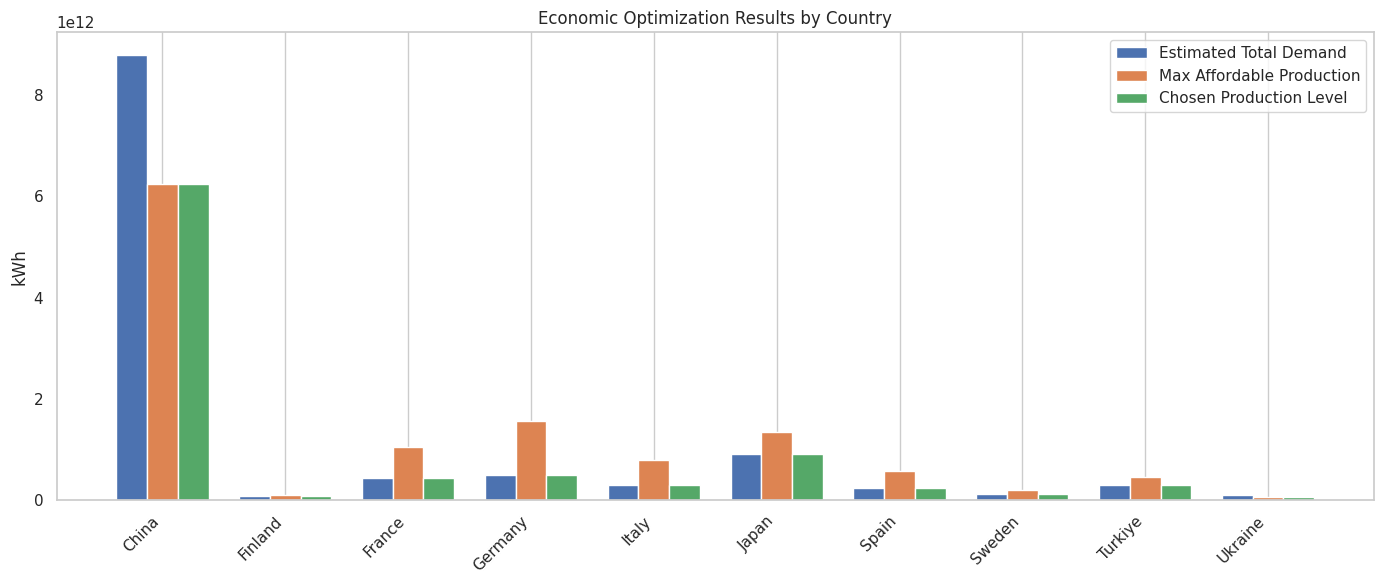

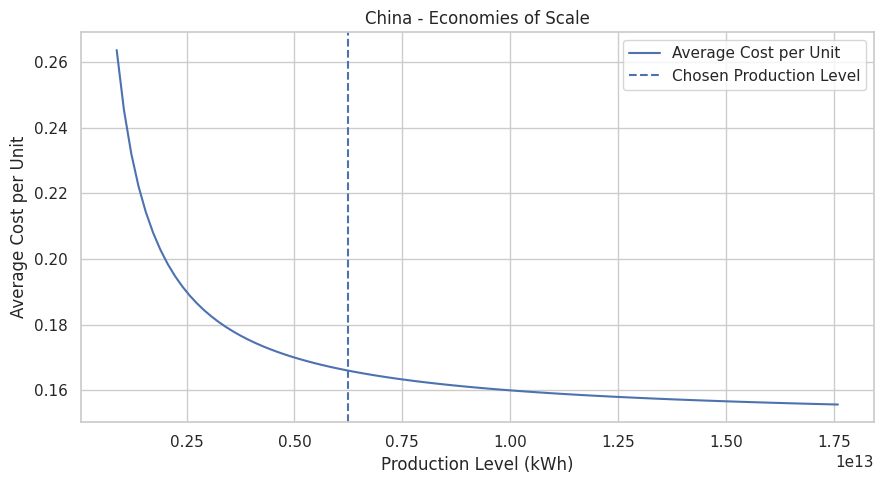

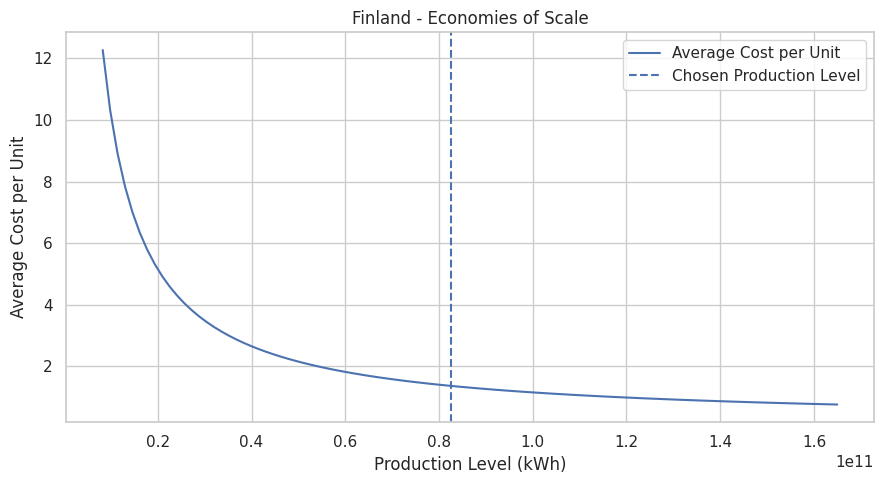

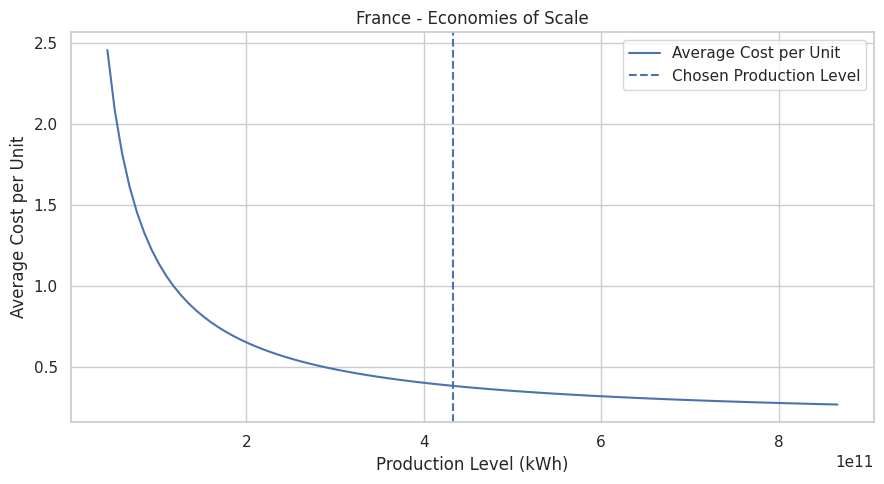

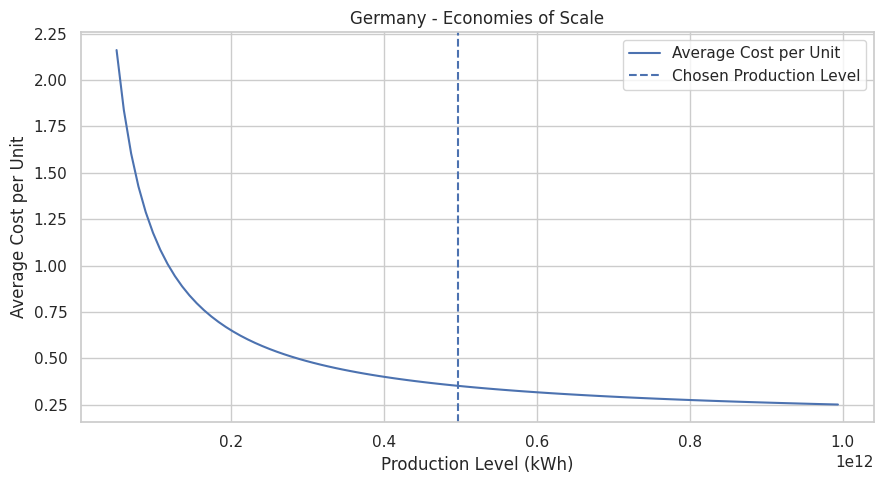

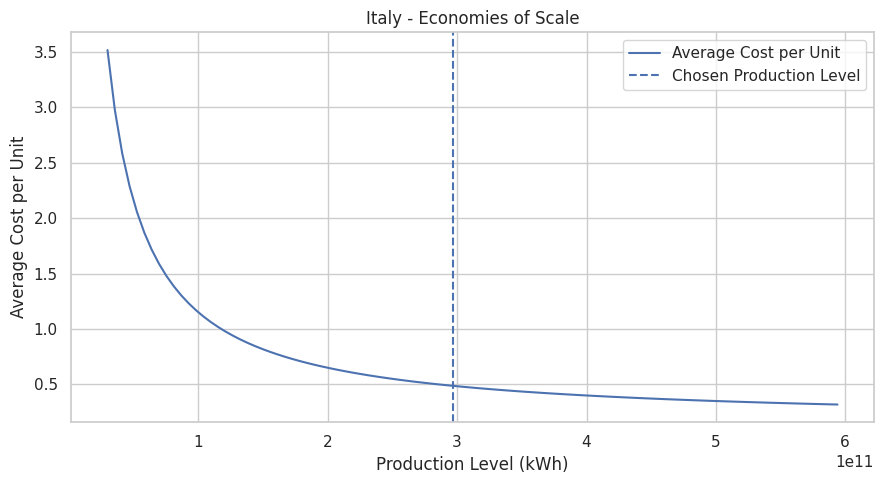

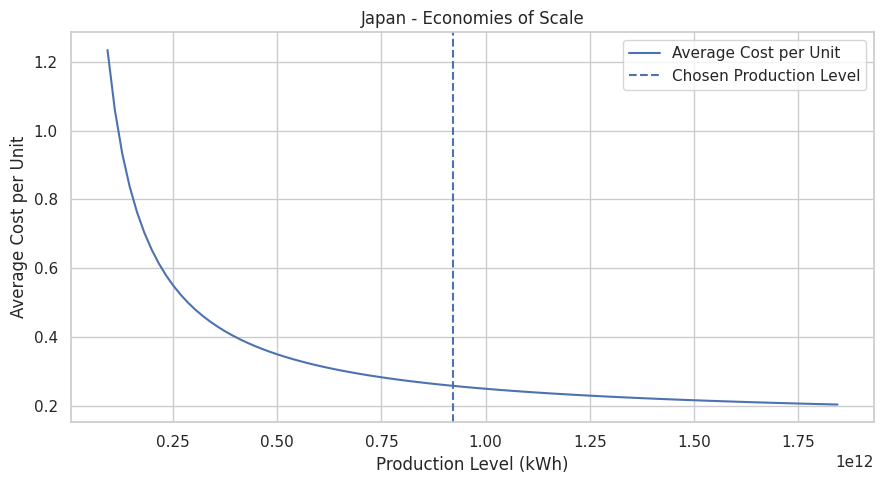

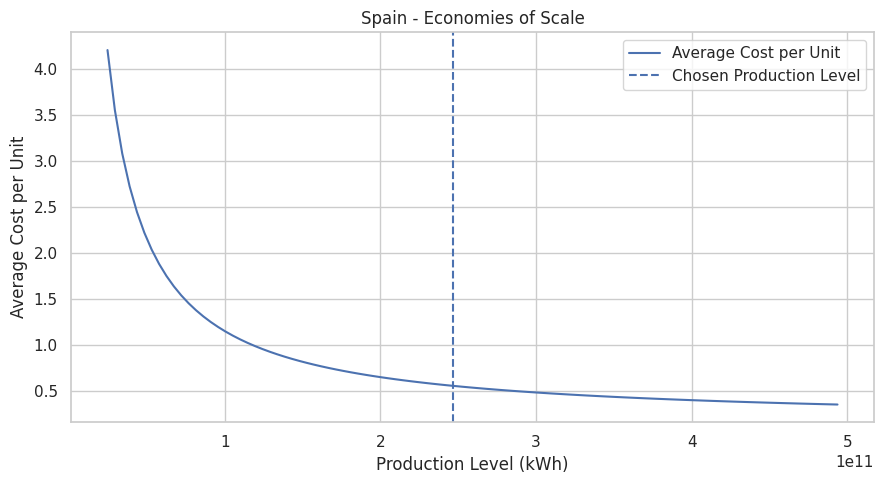

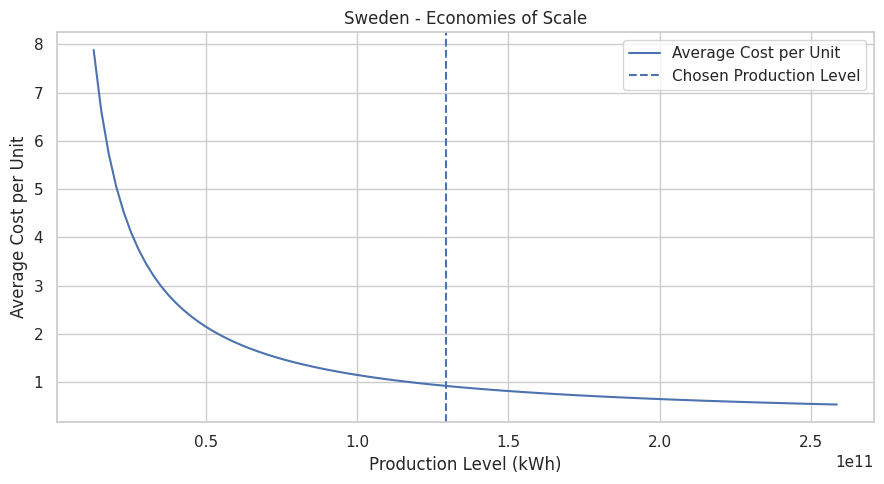

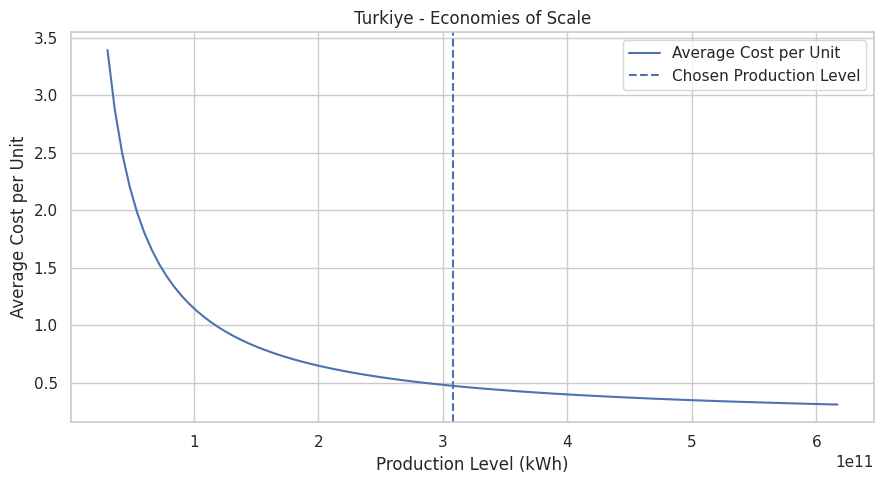

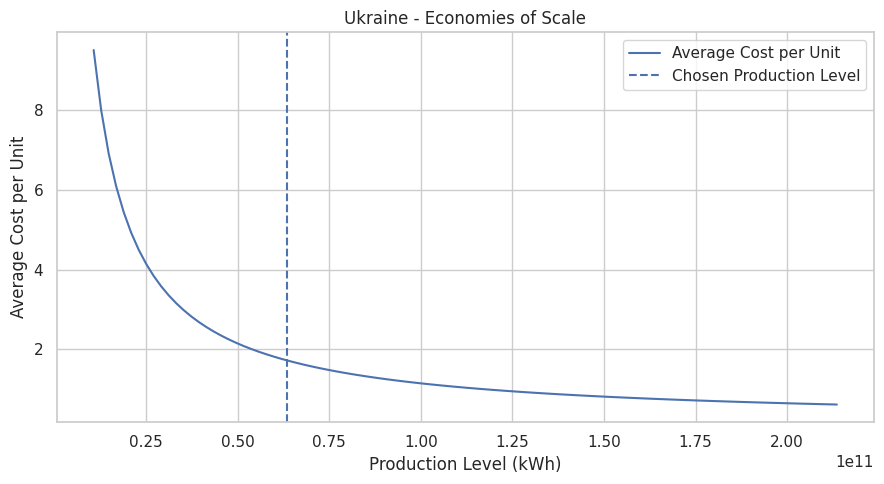

In [ ]:
# Economic optimization and economies of scale analysis for all countries

optimization_results = []

cost_per_kwh = 0.15
budget_ratio = 0.05
fixed_cost = 1e11

for country in countries:
    country_df = pivot_interpolated[
        pivot_interpolated["Country Name"] == country
    ].copy()

    country_df = country_df.sort_values("Year")

    if len(country_df) <= sequence_length:
        continue

    X = country_df[features].values
    y = country_df[target].values.reshape(-1, 1)

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y)

    X_seq, y_seq = [], []

    for i in range(len(X_scaled) - sequence_length):
        X_seq.append(X_scaled[i:i + sequence_length])
        y_seq.append(y_scaled[i + sequence_length])

    if len(X_seq) == 0:
        continue

    X_tensor = torch.tensor(np.array(X_seq), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(y_seq), dtype=torch.float32)

    model = LSTMRegressor(
        input_dim=len(features),
        hidden_dim=32,
        num_layers=2
    )

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    model.train()

    for epoch in range(50):
        optimizer.zero_grad()
        output = model(X_tensor)
        loss = criterion(output, y_tensor)
        loss.backward()
        optimizer.step()

    model.eval()

    last_sequence = X_scaled[-sequence_length:]
    last_sequence_tensor = torch.tensor(
        last_sequence[np.newaxis, :, :],
        dtype=torch.float32
    )

    with torch.no_grad():
        next_pred_scaled = model(last_sequence_tensor).numpy()

    next_pred = scaler_y.inverse_transform(next_pred_scaled)[0][0]

    latest_population = country_df["Population, total"].iloc[-1]
    latest_gdp = country_df["GDP (current US$)"].iloc[-1]
    latest_year = country_df["Year"].iloc[-1]

    total_demand_kwh = next_pred * latest_population
    budget = budget_ratio * latest_gdp
    max_affordable_production = budget / cost_per_kwh

    if max_affordable_production >= total_demand_kwh:
        production_level = total_demand_kwh
        shortage = 0
        status = "Demand fully met"
    else:
        production_level = max_affordable_production
        shortage = total_demand_kwh - production_level
        status = "Budget insufficient"

    optimization_results.append({
        "Country": country,
        "Base Year": latest_year,
        "Forecast Year": latest_year + 1,
        "Predicted Consumption per Capita (kWh)": next_pred,
        "Population": latest_population,
        "Estimated Total Demand (kWh)": total_demand_kwh,
        "GDP (current US$)": latest_gdp,
        "Budget": budget,
        "Max Affordable Production (kWh)": max_affordable_production,
        "Chosen Production Level (kWh)": production_level,
        "Unmet Demand / Shortage (kWh)": shortage,
        "Status": status
    })

optimization_df = pd.DataFrame(optimization_results)

display(optimization_df)

# Summary plot
plt.figure(figsize=(14, 6))

x = np.arange(len(optimization_df))
width = 0.25

plt.bar(
    x - width,
    optimization_df["Estimated Total Demand (kWh)"],
    width,
    label="Estimated Total Demand"
)

plt.bar(
    x,
    optimization_df["Max Affordable Production (kWh)"],
    width,
    label="Max Affordable Production"
)

plt.bar(
    x + width,
    optimization_df["Chosen Production Level (kWh)"],
    width,
    label="Chosen Production Level"
)

plt.xticks(x, optimization_df["Country"], rotation=45, ha="right")
plt.ylabel("kWh")
plt.title("Economic Optimization Results by Country")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Economies of scale plot for each country
for _, row in optimization_df.iterrows():
    country = row["Country"]
    total_demand_kwh = row["Estimated Total Demand (kWh)"]
    production_level = row["Chosen Production Level (kWh)"]

    production_range = np.linspace(
        0.1 * total_demand_kwh,
        2 * total_demand_kwh,
        100
    )

    average_cost_per_unit = (
        fixed_cost + cost_per_kwh * production_range
    ) / production_range

    plt.figure(figsize=(9, 5))

    plt.plot(
        production_range,
        average_cost_per_unit,
        label="Average Cost per Unit"
    )

    plt.axvline(
        production_level,
        linestyle="--",
        label="Chosen Production Level"
    )

    plt.title(f"{country} - Economies of Scale")
    plt.xlabel("Production Level (kWh)")
    plt.ylabel("Average Cost per Unit")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()